# Chapter 10 - Clustering Techniques
## Unsupervised Learning with KMeans and DBSCAN
Based on scikit-learn Cookbook. This notebook explores clustering methods, model selection, and cluster visualization.

## Objective
Understand how clustering groups similar observations without labeled targets and how to evaluate cluster quality.

## Theory Introduction
Clustering is an unsupervised learning task that groups similar data points together. Unlike classification, clustering does not use labels.

KMeans partitions data into K clusters by minimizing distance to cluster centroids. DBSCAN groups dense regions and can detect noise points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
plt.style.use('ggplot')

## 1. Create Synthetic Dataset

In [2]:
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.1, random_state=42)
X = StandardScaler().fit_transform(X)

Synthetic clustered data is useful for visualizing unsupervised learning behavior.

## 2. Raw Data Visualization

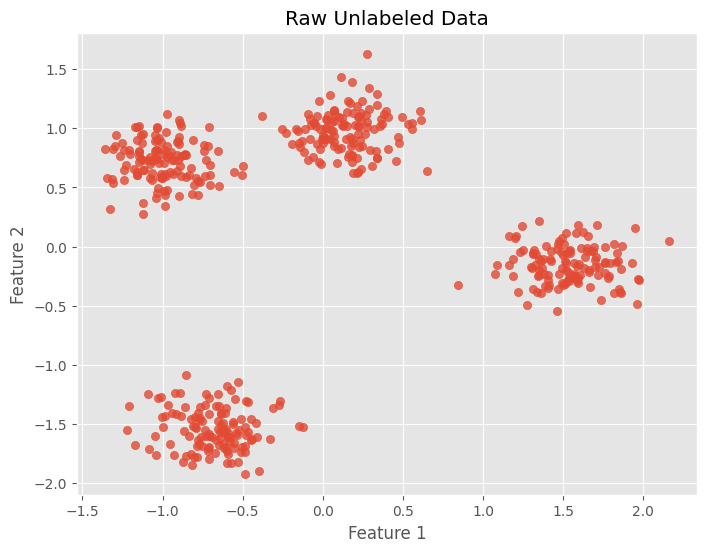

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], s=35, alpha=0.8)
plt.title('Raw Unlabeled Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Description:** Without labels, clustering algorithms attempt to discover hidden group structure.

## 3. Elbow Method for Choosing K

In [4]:
ks = range(1,11)
inertia = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

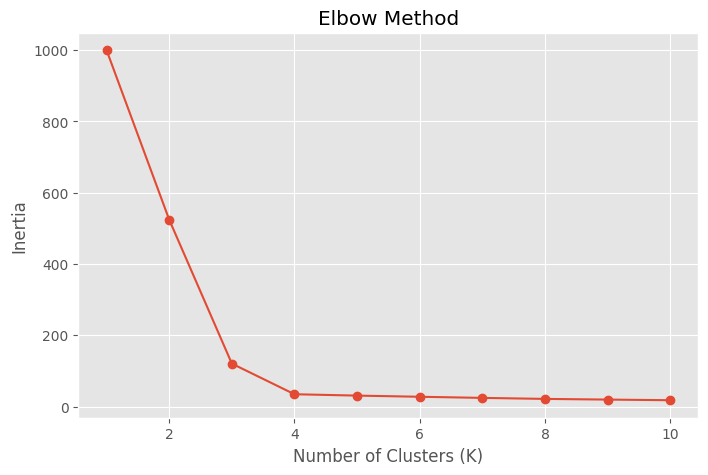

In [5]:
plt.figure(figsize=(8,5))
plt.plot(list(ks), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

**Description:** The elbow point suggests a good balance between cluster compactness and model simplicity.

## 4. KMeans Clustering (K=4)

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
score = silhouette_score(X, labels)
print('Silhouette Score:', round(score,4))

Silhouette Score: 0.7769


## 5. KMeans Cluster Visualization

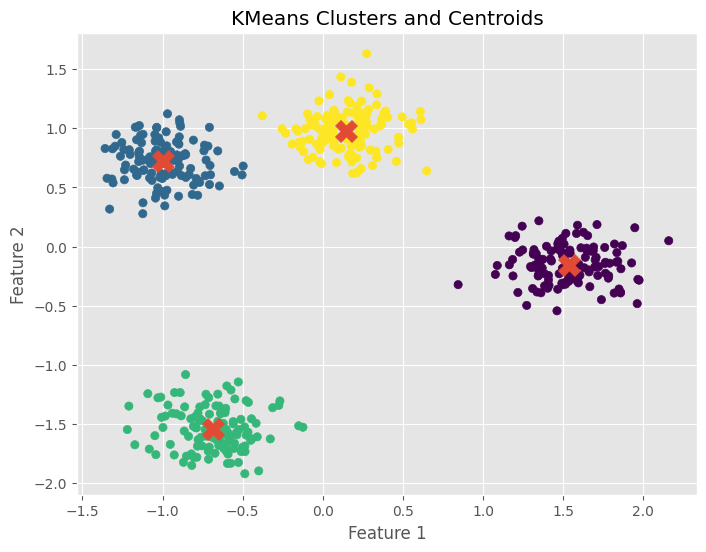

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, s=35)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='X', s=250)
plt.title('KMeans Clusters and Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Description:** Colors indicate discovered clusters, while X markers represent centroids.

## 6. DBSCAN Clustering

In [8]:
db = DBSCAN(eps=0.35, min_samples=5)
db_labels = db.fit_predict(X)

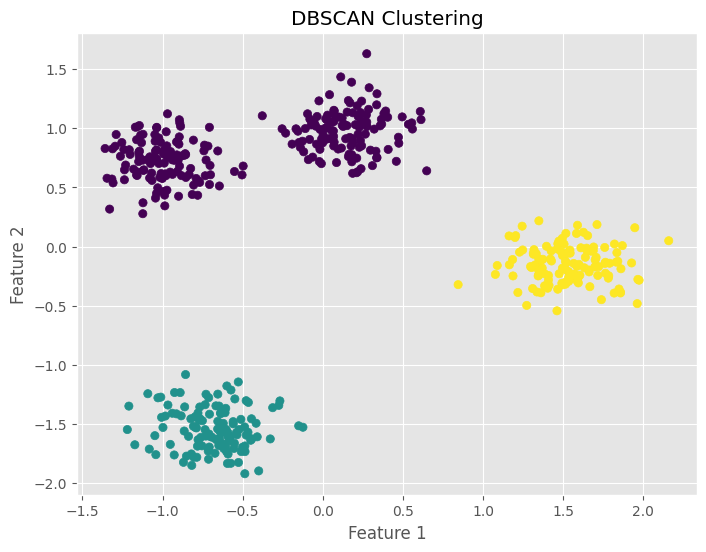

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=db_labels, s=35)
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Description:** DBSCAN identifies dense regions and may assign some points as noise (-1 label).

## 7. Cluster Size Comparison

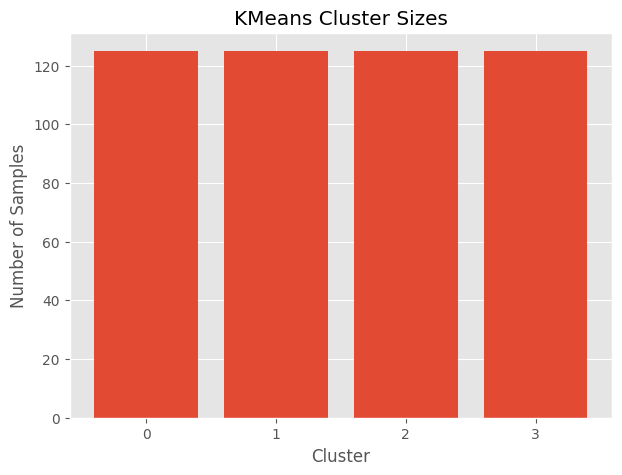

In [10]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(7,5))
plt.bar(unique.astype(str), counts)
plt.title('KMeans Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.show()

**Description:** Balanced cluster sizes may indicate stable partitioning, depending on the dataset structure.

## Important Theory Concepts
- **Centroid:** Center of a cluster in KMeans.
- **Inertia:** Within-cluster sum of squares.
- **Silhouette Score:** Measures separation and compactness.
- **DBSCAN Density:** Groups points in dense neighborhoods.
- **Noise Detection:** Outliers can remain unclustered.

## Interpretation of Results
KMeans works well for spherical clusters, while DBSCAN is useful when clusters have irregular shapes or when noise points exist.

## Summary
Clustering helps reveal hidden patterns in unlabeled data. Choosing the right algorithm depends on cluster shape, density, and noise characteristics.

## Conclusion
Use KMeans for simple compact clusters and DBSCAN when you need density-based grouping with noise detection.